# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_model_optimization as tfmot

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


2026-04-22 22:22:24.364046: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 22:22:24.366599: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-22 22:22:24.400309: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-22 22:22:24.400345: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-22 22:22:24.400373: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /home/wadhwa19/ai/projects/tinyml-arduino/lab3/UCI HAR Dataset


## 3. Load the Data


In [3]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    X_train = np.loadtxt(root_dir / "train" / "X_train.txt", dtype=np.float32)
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt", dtype=np.int32) - 1
    X_test = np.loadtxt(root_dir / "test"  / "X_test.txt",  dtype=np.float32)
    y_test = np.loadtxt(root_dir / "test"  / "y_test.txt",  dtype=np.int32)  - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [4]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [5]:

def build_teacher_model(input_dim, num_classes):
    # TODO:
    # Build a larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # TODO:
    # Build a smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               287744    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                                 
Total params: 452742 (1.73 MB)
Trainable params: 452742 (1.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. Train the Teacher Model


In [6]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(
   X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    callbacks=teacher_callbacks
)


Epoch 1/40
92/92 [==============================] - 1s 10ms/step - loss: 0.4249 - accuracy: 0.8152 - val_loss: 0.1898 - val_accuracy: 0.9205
Epoch 2/40
92/92 [==============================] - 1s 8ms/step - loss: 0.1608 - accuracy: 0.9347 - val_loss: 0.1402 - val_accuracy: 0.9395
Epoch 3/40
92/92 [==============================] - 1s 7ms/step - loss: 0.1041 - accuracy: 0.9568 - val_loss: 0.4059 - val_accuracy: 0.8620
Epoch 4/40
92/92 [==============================] - 1s 9ms/step - loss: 0.0926 - accuracy: 0.9638 - val_loss: 0.1777 - val_accuracy: 0.9347
Epoch 5/40
92/92 [==============================] - 1s 9ms/step - loss: 0.0904 - accuracy: 0.9645 - val_loss: 0.1641 - val_accuracy: 0.9286


### Teacher Training Curves


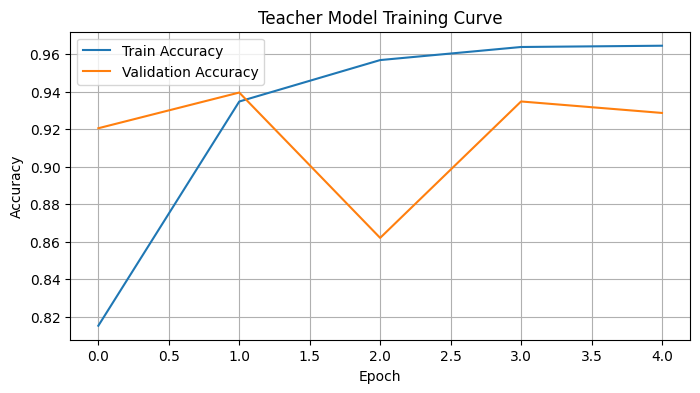

In [7]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


Teacher Test Accuracy: 0.9396

                    precision    recall  f1-score   support

           WALKING     0.9715    0.9617    0.9666       496
  WALKING_UPSTAIRS     0.9428    0.9448    0.9438       471
WALKING_DOWNSTAIRS     0.9225    0.9357    0.9291       420
           SITTING     0.8444    0.9613    0.8990       491
          STANDING     0.9653    0.8365    0.8963       532
            LAYING     0.9981    1.0000    0.9991       537

          accuracy                         0.9396      2947
         macro avg     0.9408    0.9400    0.9390      2947
      weighted avg     0.9425    0.9396    0.9396      2947



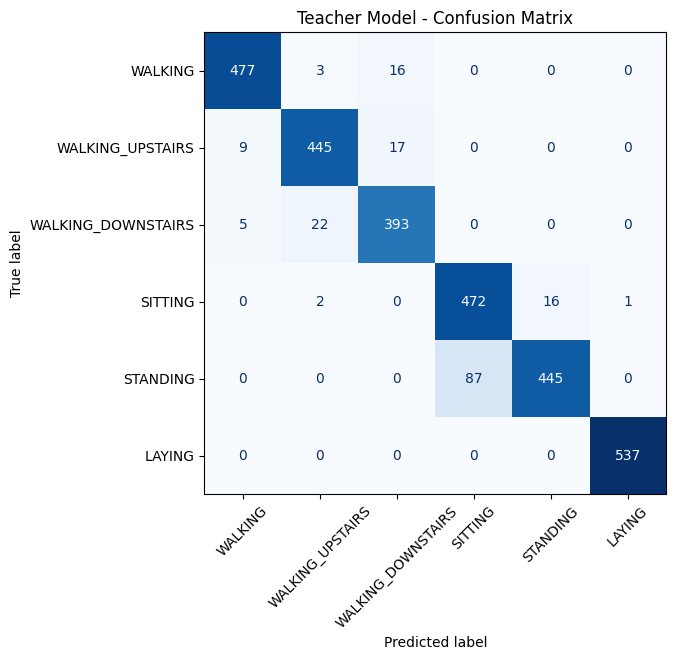

In [8]:
teacher_probs = teacher_model.predict(X_test, verbose=0)
teacher_preds = np.argmax(teacher_probs, axis=1)
test_accuracy = accuracy_score(y_test, teacher_preds)
print(f"Teacher Test Accuracy: {test_accuracy:.4f}\n")
print(classification_report(y_test, teacher_preds, target_names=class_names, digits=4))

# Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, teacher_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Teacher Model - Confusion Matrix")
plt.show()

## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [11]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]
# TODO:
# Train the baseline student using the hard labels only.
student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 4ms/step - loss: 0.0791 - accuracy: 0.9716 - val_loss: 0.1439 - val_accuracy: 0.9402
Epoch 2/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0684 - accuracy: 0.9757 - val_loss: 0.1460 - val_accuracy: 0.9395
Epoch 3/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0543 - accuracy: 0.9821 - val_loss: 0.1687 - val_accuracy: 0.9415
Epoch 4/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0567 - accuracy: 0.9793 - val_loss: 0.1437 - val_accuracy: 0.9429
Epoch 5/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0521 - accuracy: 0.9810 - val_loss: 0.1344 - val_accuracy: 0.9443
Epoch 6/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0454 - accuracy: 0.9842 - val_loss: 0.1610 - val_accuracy: 0.9470
Epoch 7/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0642 - accuracy: 0.9762 - val_loss: 0.1637 - val_accuracy: 0.9429
Epoch 8/20
92/92 [==

## 9. Evaluate the Baseline Student Model


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 64)                35968     
                                                                 
 dense_5 (Dense)             (None, 32)                2080      
                                                                 
 dense_6 (Dense)             (None, 6)                 198       
                                                                 
Total params: 38246 (149.40 KB)
Trainable params: 38246 (149.40 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


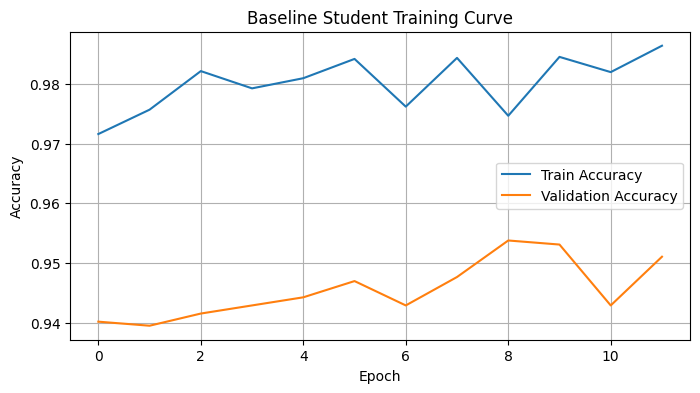

Baseline Student Test Accuracy: 0.9335

                    precision    recall  f1-score   support

           WALKING     0.9550    0.9415    0.9482       496
  WALKING_UPSTAIRS     0.9603    0.9236    0.9416       471
WALKING_DOWNSTAIRS     0.9040    0.9643    0.9332       420
           SITTING     0.9628    0.8432    0.8990       491
          STANDING     0.8418    0.9699    0.9013       532
            LAYING     1.0000    0.9572    0.9781       537

          accuracy                         0.9335      2947
         macro avg     0.9373    0.9333    0.9336      2947
      weighted avg     0.9376    0.9335    0.9338      2947



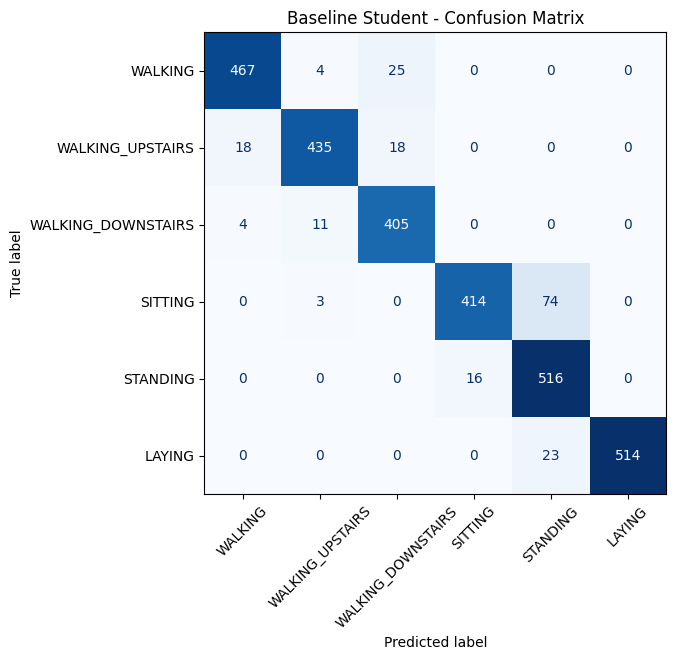

In [29]:
student_baseline_model.summary()
# Training Curve
baseline_student_history_df = pd.DataFrame(student_baseline_history.history)
plt.figure(figsize=(8, 4))
plt.plot(baseline_student_history_df["accuracy"], label="Train Accuracy")
plt.plot(baseline_student_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy & Classification Report
baseline_probs = student_baseline_model.predict(X_test, verbose=0)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_acc = accuracy_score(y_test, baseline_preds)
print(f"Baseline Student Test Accuracy: {baseline_acc:.4f}\n")
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

# Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Student - Confusion Matrix")
plt.show()

In [13]:

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # TODO:
        # 1. Obtain teacher predictions with training=False
        # 2. Compute student predictions inside GradientTape
        # 3. Compute student_loss using the hard labels
        # 4. Compute distillation_loss using softened teacher/student outputs
        # 5. Combine the two losses using alpha
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)

            student_loss = self.student_loss_fn(y, student_predictions)

            distillation_loss =  self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            )

            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


## 11. Train the Distilled Student

In [31]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the distilled student.
distillation_history = distiller.fit(
  X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    callbacks=distillation_callbacks
)


Epoch 1/40
92/92 [==============================] - 1s 7ms/step - accuracy: 0.6982 - student_loss: 0.8097 - distillation_loss: 0.0021 - val_accuracy: 0.8763 - val_student_loss: 0.2746
Epoch 2/40
92/92 [==============================] - 1s 7ms/step - accuracy: 0.9015 - student_loss: 0.3045 - distillation_loss: 6.0598e-04 - val_accuracy: 0.9103 - val_student_loss: 0.0308
Epoch 3/40
92/92 [==============================] - 1s 6ms/step - accuracy: 0.9288 - student_loss: 0.1984 - distillation_loss: 3.2899e-04 - val_accuracy: 0.9259 - val_student_loss: 0.0096
Epoch 4/40
92/92 [==============================] - 0s 5ms/step - accuracy: 0.9500 - student_loss: 0.1431 - distillation_loss: 2.0419e-04 - val_accuracy: 0.9320 - val_student_loss: 0.0041
Epoch 5/40
92/92 [==============================] - 1s 5ms/step - accuracy: 0.9587 - student_loss: 0.1175 - distillation_loss: 1.7017e-04 - val_accuracy: 0.9300 - val_student_loss: 0.0019
Epoch 6/40
92/92 [==============================] - 0s 5ms/step 

### Distillation Training Curves


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 64)                35968     
                                                                 
 dense_11 (Dense)            (None, 32)                2080      
                                                                 
 dense_12 (Dense)            (None, 6)                 198       
                                                                 
Total params: 38246 (149.40 KB)
Trainable params: 38246 (149.40 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


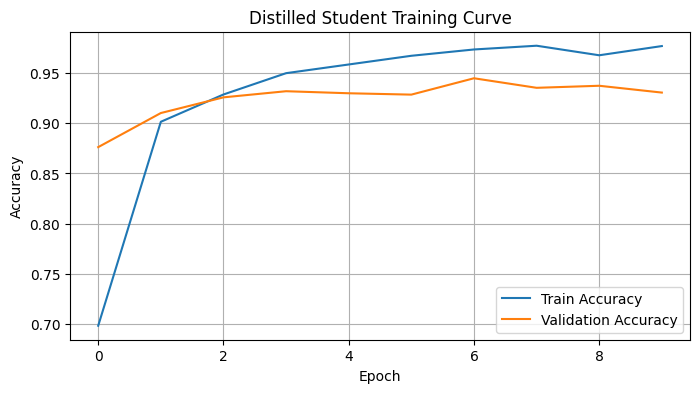

In [33]:
distilled_student.summary()
distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9253

                    precision    recall  f1-score   support

           WALKING     0.9606    0.9335    0.9468       496
  WALKING_UPSTAIRS     0.9550    0.9002    0.9268       471
WALKING_DOWNSTAIRS     0.8664    0.9571    0.9095       420
           SITTING     0.8762    0.8941    0.8851       491
          STANDING     0.8945    0.8929    0.8937       532
            LAYING     0.9981    0.9758    0.9868       537

          accuracy                         0.9253      2947
         macro avg     0.9251    0.9256    0.9248      2947
      weighted avg     0.9271    0.9253    0.9257      2947



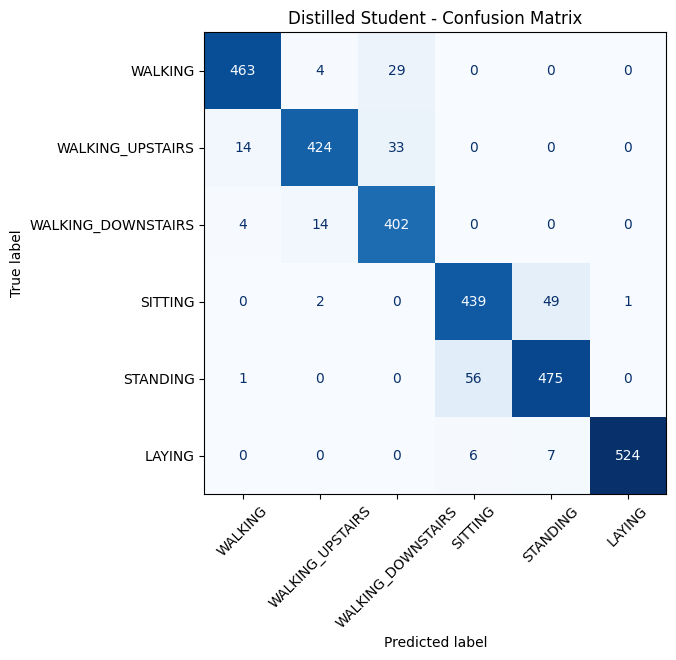

In [16]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()



In [17]:
print(f"Diff between baseline and distilled student: {distilled_acc - baseline_acc:+.4f}")    

Diff between baseline and distilled student: -0.0081


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [22]:
print("=" * 65)
print("Part I Comparison: Teacher vs Student vs Distilled Student")
print("=" * 65)

results = pd.DataFrame([
    {
        "Model"       : "Teacher DNN",
        "Accuracy"    : test_accuracy,
        "Params"      : teacher_model.count_params(),
    },
    {
        "Model"       : "Baseline Student",
        "Accuracy"    : baseline_acc,
        "Params"      : student_baseline_model.count_params(),
    },
    {
        "Model"       : "Distilled Student",
        "Accuracy"    : distilled_acc,
        "Params"      : distilled_student.count_params(),
    },
])

results["Accuracy"] = results["Accuracy"].round(4)
results["KD Gain vs Baseline"] = (results["Accuracy"] - baseline_acc).round(4)

print(results.to_string(index=False))
print("=" * 65)

Part I Comparison: Teacher vs Student vs Distilled Student
            Model  Accuracy  Params  KD Gain vs Baseline
      Teacher DNN    0.9396  452742               0.0061
 Baseline Student    0.9335   38246               0.0000
Distilled Student    0.9253   38246              -0.0082


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [19]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)
        
         # TODO:
        # Quantize the input when the model expects int8/uint8 input.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])
        
        # TODO:
        # Dequantize the output when needed.
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
     # TODO:
    # Yield small batches from X_train for calibration.
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


## 15. Convert the Distilled Student to TensorFlow Lite


In [20]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.
student_for_pruning = keras.models.clone_model(distilled_student)
student_for_pruning.set_weights(distilled_student.get_weights())

pruned_distilled_model = tfmot.sparsity.keras.prune_low_magnitude(
    student_for_pruning,
    **pruning_params
)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1
pruning_history = pruned_distilled_model.fit(
   X_train, y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/10
92/92 [==============================] - 2s 5ms/step - loss: 0.1399 - accuracy: 0.9549 - val_loss: 0.1720 - val_accuracy: 0.9252
Epoch 2/10
92/92 [==============================] - 0s 4ms/step - loss: 0.1540 - accuracy: 0.9495 - val_loss: 0.1710 - val_accuracy: 0.9347
Epoch 3/10
92/92 [==============================] - 0s 3ms/step - loss: 0.2009 - accuracy: 0.9405 - val_loss: 0.1965 - val_accuracy: 0.9415
Epoch 4/10
92/92 [==============================] - 0s 3ms/step - loss: 0.3086 - accuracy: 0.9089 - val_loss: 0.2401 - val_accuracy: 0.9409
Epoch 5/10
92/92 [==============================] - 0s 3ms/step - loss: 0.4259 - accuracy: 0.8641 - val_loss: 0.3730 - val_accuracy: 0.9361
Epoch 6/10
92/92 [==============================] - 0s 3ms/step - loss: 1.0542 - accuracy: 0.7232 - val_loss: 1.1074 - val_accuracy: 0.7063


## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [21]:

# TODO:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmp0ppuvxrw/assets


INFO:tensorflow:Assets written to: /tmp/tmp0ppuvxrw/assets
2026-04-22 22:30:35.044718: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 22:30:35.044781: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 22:30:35.045505: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp0ppuvxrw
2026-04-22 22:30:35.046970: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 22:30:35.046991: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp0ppuvxrw
2026-04-22 22:30:35.051405: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-22 22:30:35.052691: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 22:30:35.094358: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmp6ba7cir4/assets


INFO:tensorflow:Assets written to: /tmp/tmp6ba7cir4/assets


Pruned distilled model with mask accuracy: 0.9196
Pruned distilled model with mask size (KB): 304.25
Stripped sparse distilled model accuracy: 0.9196
Stripped sparse distilled model size (KB): 105.85


2026-04-22 22:30:35.636449: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 22:30:35.636552: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 22:30:35.636701: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp6ba7cir4
2026-04-22 22:30:35.637140: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 22:30:35.637153: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp6ba7cir4
2026-04-22 22:30:35.638536: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 22:30:35.651829: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp6ba7cir4
2026-04-22 22:30:35.656665: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 19963 m

## 17. Convert the Pruned Distilled Student Before and After Stripping


In [23]:

# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset =tf.lite.RepresentativeDataset(representative_data_gen)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpvxcnjf0u/assets


INFO:tensorflow:Assets written to: /tmp/tmpvxcnjf0u/assets
/home/wadhwa19/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-22 22:34:06.941778: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 22:34:06.941828: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 22:34:06.942060: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpvxcnjf0u
2026-04-22 22:34:06.942532: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 22:34:06.942546: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpvxcnjf0u
2026-04-22 22:34:06.943705: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.


Stripped Sparse + INT8 Accuracy: 0.9213
Stripped Sparse + INT8 Size (KB): 54.77


## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [24]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpfsb8s47q/assets


INFO:tensorflow:Assets written to: /tmp/tmpfsb8s47q/assets


Stripped Sparse + INT8 Accuracy: 0.9213
Stripped Sparse + INT8 Size (KB): 54.77


/home/wadhwa19/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-22 22:34:09.779611: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 22:34:09.779650: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 22:34:09.779776: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpfsb8s47q
2026-04-22 22:34:09.780225: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 22:34:09.780236: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpfsb8s47q
2026-04-22 22:34:09.781370: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 22:34:09.793014: I tensorflow/cc/saved_model/loa

## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [25]:
# Convert distilled student to FP32 TFLite
distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)
distilled_fp32_size_kb = save_binary_model(distilled_fp32_tflite, "distilled_student_fp32.tflite")
distilled_fp32_acc, distilled_fp32_preds = evaluate_tflite_model(distilled_fp32_tflite, X_test, y_test)

print(f"Distilled Student FP32 Accuracy : {distilled_fp32_acc:.4f}")
print(f"Distilled Student FP32 Size (KB): {distilled_fp32_size_kb:.2f}")

INFO:tensorflow:Assets written to: /tmp/tmpm64ycy5i/assets


INFO:tensorflow:Assets written to: /tmp/tmpm64ycy5i/assets


Distilled Student FP32 Accuracy : 0.9253
Distilled Student FP32 Size (KB): 151.48


2026-04-22 22:34:11.467523: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 22:34:11.467571: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 22:34:11.467704: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpm64ycy5i
2026-04-22 22:34:11.468067: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 22:34:11.468075: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpm64ycy5i
2026-04-22 22:34:11.468991: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 22:34:11.480139: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpm64ycy5i
2026-04-22 22:34:11.484586: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 16881 m

In [26]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.925348,151.476562
1,Pruned Distilled TFLite (with mask),FP32,0.919579,304.253906
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.919579,105.847656
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.921276,54.765625


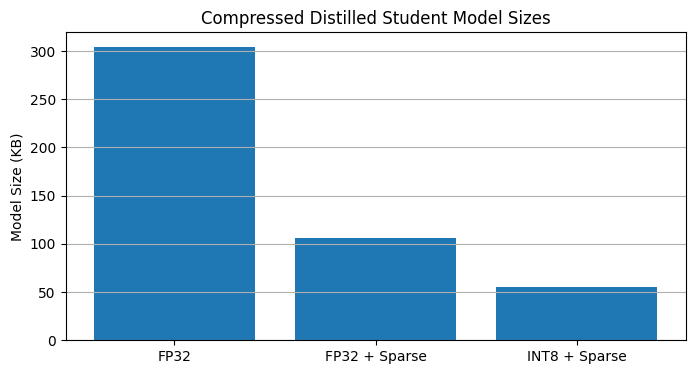

In [27]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


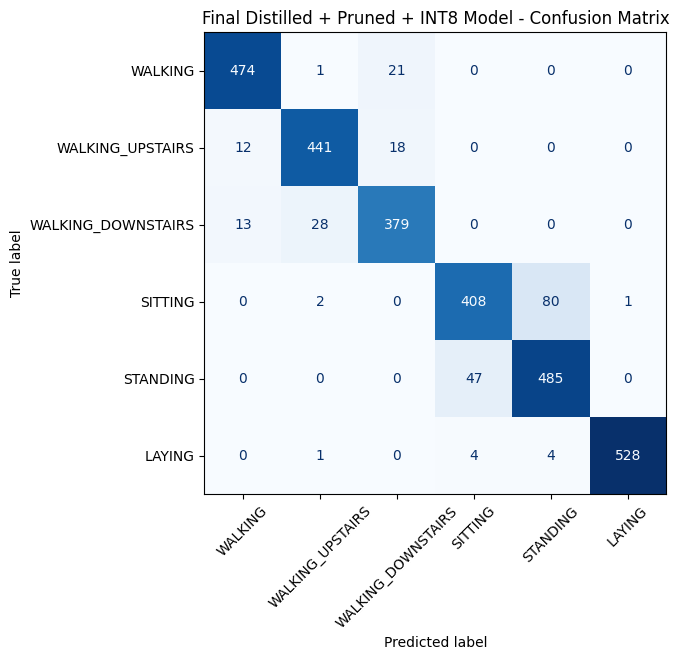

In [28]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**?
2. Did **knowledge distillation** help the smaller model retain performance?
3. What happened to the model size after **pruning** and after **INT8 quantization**?
4. Which model would you choose for **Arduino deployment**, and why?
5. Why is the final **sparse INT8 model** a good TinyML deployment candidate?


#### A1.
The baseline student showed better validation accuracy compared to distilled student.Although the student model was smaller there was not a significant drop in accuracy. This might be due to well balanced dataset and labels were supportive enough for good results.
#### A2. 
No, in this case knowledge distillation didn't show any significant results. Contrary to what was expected, the accuracy dropped slightly by 0.0081% compared to baseline.

#### A3.
After pruning without the mask size was 105.84 KB and after quantization size was 54.76 KB. Originally the size was 151.47 KB . So the size of distilled student decreased with quantiszation and pruning.

#### A4.
I would Stripped Sparse Distilled student TFLite INT8 due to its small size and good accuracy.

#### A5.
This model leverages all the model compression techniques and reduces the initial size that was around 1.73 KB to only 54 KB whilst also maintaining accuracy of prediction.

## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
